<a href="https://colab.research.google.com/github/vishaljoshi24/Dungeons-and-Dragons-Turn-Classification/blob/main/annotator_agreement.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import matplotlib.pyplot as ply
import pandas as pd
import numpy as np

In [2]:
df = pd.read_excel('labelled_trainset_initial_codes.xlsx')

In [3]:
df

,Column1,context,current turn,category jack,category vishal
0,113,Dialogue context: MATT: You've all gathered yo...,"LIAM: Percival, do you know anything-- Do you ...",Strategising,Cooperative roleplay
1,114,Dialogue context: SAM: We're in the crypt? The...,TALIESIN: I don't think so.,Strategising,Cooperative roleplay
2,115,Dialogue context: MATT: That's the actual offi...,"MATT: No, the back wall of this mausoleum was ...",Theatre of Mind,Clarifying game state
3,116,"Dialogue context: LIAM: Percival, do you know ...",ALL: Whoa!,Acknowledgment,Simple Reaction
4,117,Dialogue context: TALIESIN: I don't think so. ...,MATT: We got a Laura Bailey!,Out of Character discussion,Chit-chat
...,...,...,...,...,...
379,492,Dialogue context: LAURA: Seven. MATT: Seven? O...,TRAVIS: Heroes' Feast!,Humourous Gameplay,Open-ended roleplay
380,493,Dialogue context: MATT: Seven? Okay. You suffe...,"LAURA: And Trinket ate it, too!",Strategising,Cooperative roleplay
381,494,"Dialogue context: SAM: Grog, you suffer no poi...",MARISHA: That's true!,Acknowledgment,Simple Reaction
382,495,Dialogue context: TRAVIS: Heroes' Feast! LAURA...,LAURA: We're immune to poison?,Gameplay Questions,Gameplay question


In [4]:
annotator_1 = df['category vishal']

In [5]:
annotator_2 = df['category jack']

In [11]:
agreement_df = pd.concat([annotator_1, annotator_2], axis=1, keys=['labels 1', 'labels 2'])

In [16]:
labels_1 = agreement_df['labels 1'].unique()

In [17]:
labels_2 = agreement_df['labels 2'].unique()

In [59]:
corresponding_labels = []
counts_list = []

def countsFunction():
  for label in labels_1:
    df_labels_1 = agreement_df[agreement_df['labels 1'] == label]
    corresponding_labels.append(df_labels_1)
    counts = df_labels_1.value_counts().to_frame(name='counts_df')
    counts_list.append(counts)
    print(counts_list)
  return counts_list

In [60]:
counts = countsFunction()

[                                         counts_df
labels 1             labels 2                     
Cooperative roleplay Strategising               55
                     Gameplay Action             8
                     Basic Roleplay              6
                     Humourous Gameplay          4
                     Clarification               1
                     Gameplay Questions          1]
[                                         counts_df
labels 1             labels 2                     
Cooperative roleplay Strategising               55
                     Gameplay Action             8
                     Basic Roleplay              6
                     Humourous Gameplay          4
                     Clarification               1
                     Gameplay Questions          1,                                        counts_df
labels 1              labels 2                  
Clarifying game state Theatre of Mind          1]
[                               

In [63]:
annotations_df = pd.concat(counts_list)

In [64]:
annotations_df

counts_df
labels 1              labels 2                              
Cooperative roleplay  Strategising                        55
                      Gameplay Action                      8
                      Basic Roleplay                       6
                      Humourous Gameplay                   4
                      Clarification                        1
                      Gameplay Questions                   1
Clarifying game state Theatre of Mind                      1
Simple Reaction       Acknowledgment                      20
                      Basic Roleplay                       5
                      Clarification                        5
                      Humourous Gameplay                   3
                      Strategising                         3
                      Meta Conversation                    2
                      Gameplay Action                      1
Chit-chat             Out of Character discussion         20
                      Meta Conversation                    3
Conversational repair Out of Character discussion          1
Humour                Out of Character discussion          3
                      Gameplay Action                      1
Game Master direction Rules Ruling                        18
                      Theatre of Mind                     14
                      Basic Roleplay                       3
                      Gameplay Questions                   3
                      Acknowledgment                       2
                      Meta Conversation                    1
                      Out of Character discussion          1
                      Strategising                         1
Purposeful roleplay   Strategising                        10
                      Gameplay Action                      7
                      Clarification                        2
Gameplay information  Gameplay Action                     16
                      Strategising                         8
                      Rules Ruling                         5
                      Clarification                        2
                      Basic Roleplay                       1
                      Acknowledgment                       1
                      Humourous Gameplay                   1
                      Gameplay Questions                   1
                      Preemptive Gameplay Action           1
                      Out of Character discussion          1
Gameplay question     Gameplay Questions                  26
                      Strategising                         6
                      Gameplay Action                      3
                      Meta Conversation                    1
                      Out of Character discussion          1
Open-ended roleplay   Basic Roleplay                      38
                      Strategising                        19
                      Humourous Gameplay                  12
                      Meta Conversation                   11
                      Gameplay Action                      7
                      Acknowledgment                       3
                      Contesting Actions                   1
                      Gameplay Questions                   1
                      Sharing Information                  1
Game Master action    Basic Roleplay                       6
                      Strategising                         6

<Axes: xlabel='labels 2', ylabel='labels 1'>

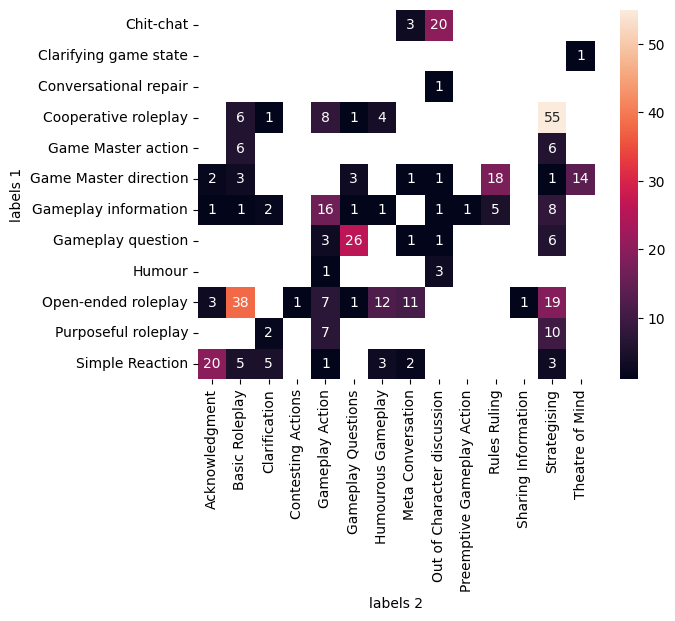

In [69]:
import seaborn as sns
sns.heatmap(annotations_df.pivot_table(index='labels 1', columns='labels 2', values='counts_df'), annot=True)

In [70]:
import matplotlib.pyplot as plt
plt.savefig('open_codes_heatmap')

<Figure size 640x480 with 0 Axes>